# AG-HYPOPT · Trial 09

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Eight trials are registered; cell 2 reports `phase = trials` (8/5), so proposals carry expected-improvement (ei) values. **Best = trial_08** (objective 0.1099, a new best that beat trial_01). Ranking with mu travel = `lr_mu*(1 - mu_anneal/2)`:

- **trial_08 (0.1099, best, 0 div):** `lr_mu=0.1616`, `mu_anneal=0.3475`, `lr_gamma=0.4157`, `gamma_anneal=0.5318` (travel 0.134). mu rel-RMSE 76.5%, gamma 23.1%; 1nW high-T mu undershoot essentially gone (T60 -2.7%, T100 -2.5%).
- **trial_01 (0.1127, 0 div):** `lr_mu=0.1551`, `mu_anneal=0.4535`, `lr_gamma=0.7990`, `gamma_anneal=0.2968` (travel 0.120); mu 77.1%, gamma 21.5%.
- **trial_05 (0.1135, 0 div):** travel 0.088; mu 56.6%, gamma 23.8%.
- **trial_07 (0.1140, 0 div):** `lr_mu=0.1159`, `mu_anneal=0.3324`, `lr_gamma=0.8120`, `gamma_anneal=0.3019` (travel 0.097); mu 62.0%, gamma 21.6%.
- **trial_06 (0.1188, 0 div):** travel 0.082; mu 57.6%, gamma 24.1%.
- **trials 03 / 04 / 02 (0.1362 / 0.1418 / 0.1449, 1 div each):** travels 0.074 / 0.074 / 0.264; all diverged at 1nW T05.

Key new signal from trial_08: within the good band, the *upper* edge of mu travel (0.134) is better than the lower edge (0.082-0.097). The larger travel nearly removed the heavily-weighted 1nW high-T mu undershoot, which outweighed its larger low/mid-T overshoots and produced the new best. The 3nW high-T cells still undershoot (~-22% / -37%) and the low-T gamma under-recovery (1nW T05 ~-49%) is unchanged in every divergence-free run. Objective = T-weighted (w=0.25+0.75*T/100) mean of capped rel-sq errors over the 8-experiment benchmark.

In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_09'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 40    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (8/5 trials)
ID |     ei | params
 1 | 3.9102 | {"gamma_anneal": 0.5416139963353477, "lr_gamma": 0.4805473089982995, "lr_mu": 0.14863351086147128, "mu_anneal": 0.3504215766434031}
 2 | 3.7473 | {"gamma_anneal": 0.39352320011655784, "lr_gamma": 0.49861312191045903, "lr_mu": 0.4161576113007722, "mu_anneal": 0.350732090113323}
 3 | 0.1792 | {"gamma_anneal": 0.6348003341305084, "lr_gamma": 0.7537110587319613, "lr_mu": 0.3923825030874251, "mu_anneal": 0.3746203361007758}
 4 | 3.8402 | {"gamma_anneal": 0.5162693702460148, "lr_gamma": 0.3932592110879737, "lr_mu": 0.12801396747211868, "mu_anneal": 0.31345294482209546}
 5 | 2.2551 | {"gamma_anneal": 0.4302265394283672, "lr_gamma": 0.10914082254583024, "lr_mu": 0.48157688453399555, "mu_anneal": 0.22609832736317137}
 6 | 2.8201 | {"gamma_anneal": 0.49344377775185355, "lr_gamma": 0.39651455929342494, "lr_mu": 0.15525826130933768, "mu_anneal": 0.18933201942823097}
 7 | 3.4641 | {"gamma_anneal": 0.4114934995498707, "lr_gamma": 0.2109

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

Cell 2 is in the informed `trials` phase (8 trials). I rank by expected improvement and check each against where the evidence lives (the divergence-free runs cluster at travel 0.082-0.134 with `lr_gamma` ~0.40-0.81). Candidate travel `lr_mu*(1 - mu_anneal/2)`:
- candidate 1: **ei 3.91** — `lr_mu=0.149`, `mu_anneal=0.350` (travel **0.123**), `lr_gamma=0.481`, `gamma_anneal=0.542`.
- candidate 4: ei 3.84 — `lr_mu=0.128`, `mu_anneal=0.313` (travel 0.108), `lr_gamma=0.393`, `gamma_anneal=0.516`.
- candidate 8: ei 3.79 — `lr_mu=0.173`, `mu_anneal=0.351` (travel 0.143), `lr_gamma=0.221`, `gamma_anneal=0.492`.
- candidate 2: ei 3.75 — `lr_mu=0.416`, `mu_anneal=0.351` (travel 0.343, the trial_02 direction), `lr_gamma=0.499`.
- candidate 7: ei 3.46 — `lr_mu=0.134`, `mu_anneal=0.343` (travel 0.111), `lr_gamma=0.211`.

Candidate 1 has the highest ei and is directly adjacent to the new best trial_08: its mu knobs (`lr_mu=0.149`, `mu_anneal=0.350`) and gamma knobs (`lr_gamma=0.481`, `gamma_anneal=0.542`) are close to trial_08's (`0.162`/`0.348`, `0.416`/`0.532`), with mu travel 0.123 vs trial_08's 0.134. That makes it a fine-grained refinement inside the region that just produced the best result — exactly what is wanted after a new best. Candidates 4 and 7 are also in the band but at lower travel (0.108/0.111) and candidate 7 has a low `lr_gamma=0.211` (untested region); candidate 8 extends travel upward (0.143) but with the same low `lr_gamma=0.221`; candidate 2 is far outside at 0.343 (the trial_02 direction). So candidate 1 is the highest-ei, lowest-risk refinement of the current best.

I choose candidate 1 (1 goes into the SET cell below).

In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 1            # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'gamma_anneal': 0.5416139963353477, 'lr_gamma': 0.4805473089982995, 'lr_mu': 0.14863351086147128, 'mu_anneal': 0.3504215766434031}
Running  1nW Trans05 ... 

μ 9.39 -> 10.26 | γ 8.5 -> 4.16 | NLL 1.27


Running  1nW Trans20 ... 

μ 17.32 -> 42.98 | γ 8.5 -> 6.21 | NLL 5.50


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 77.74 | γ 14.1 -> 14.48 | NLL 3.22


Running 3nW Trans100 ... 

μ 175.71 -> 105.73 | γ 14.1 -> 14.00 | NLL 3.38



Total: 8.0 min


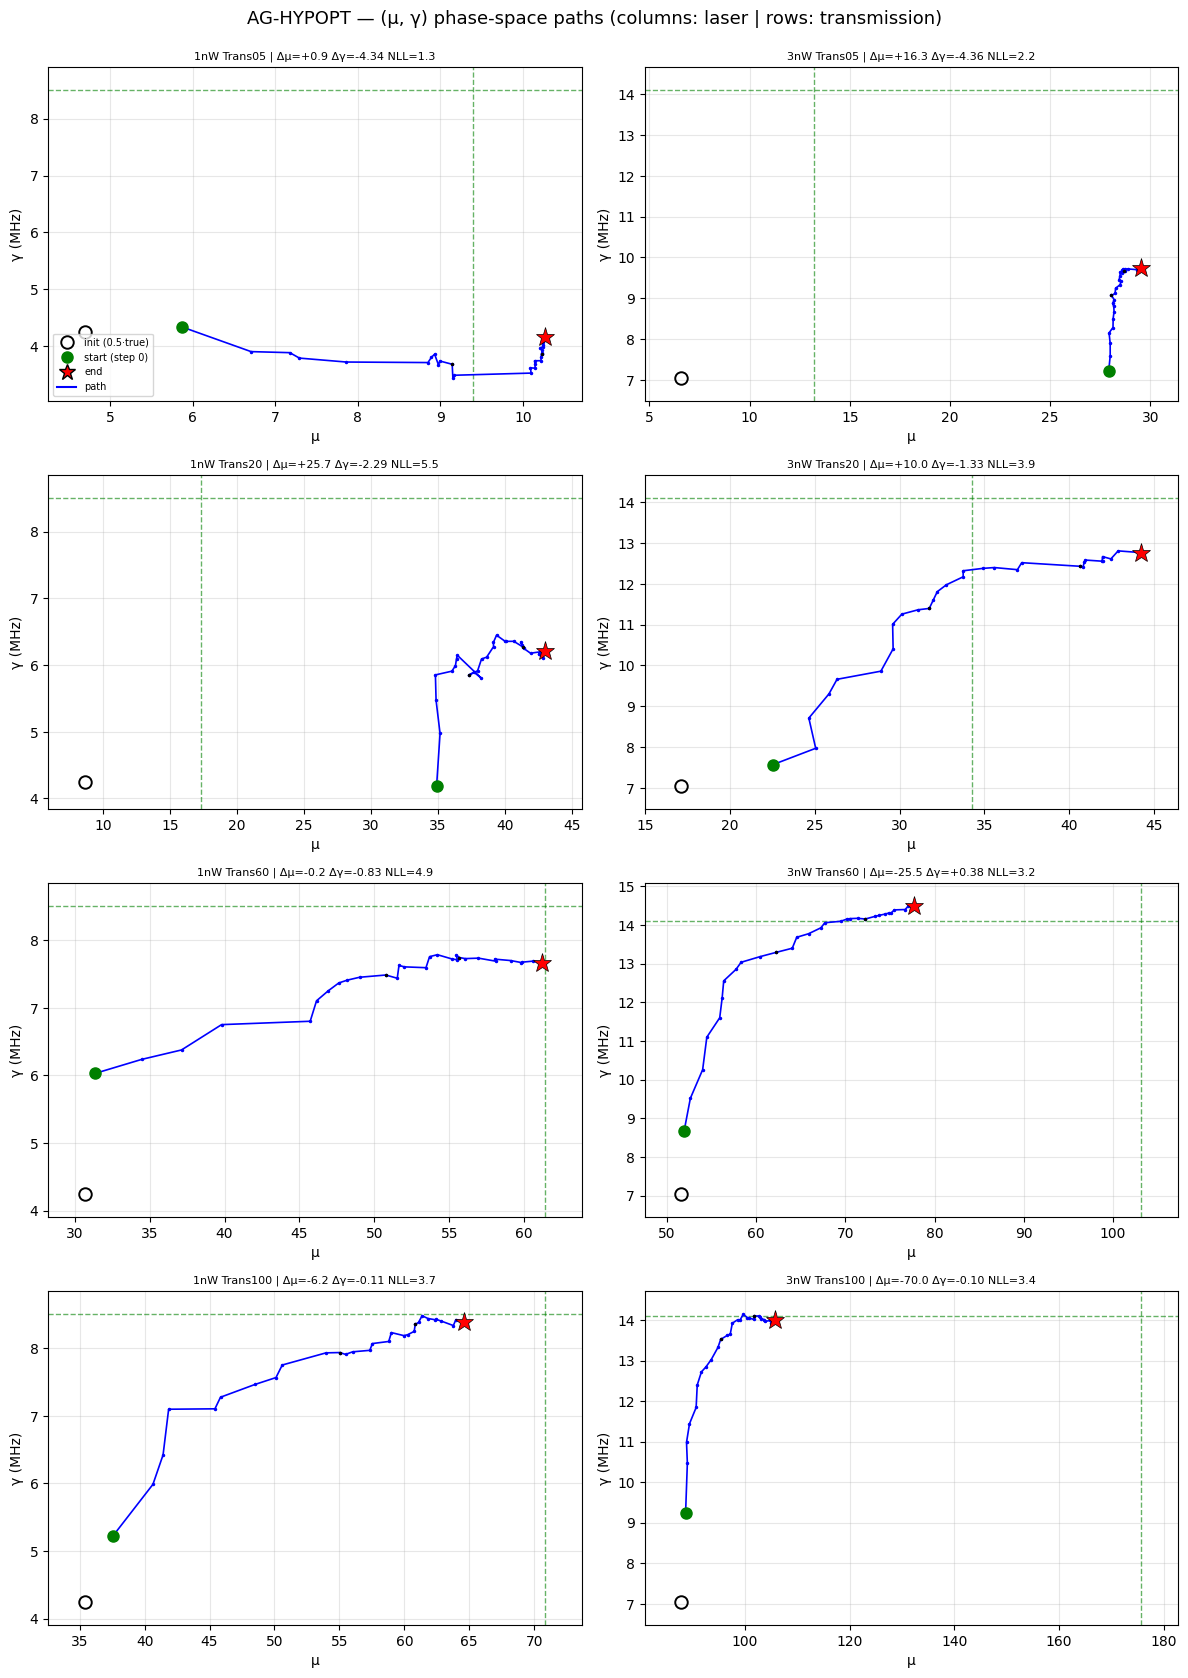

trial finished in 8.0 min
objective = 0.1126 ± 0.0827
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39   10.26    +9.3 |     8.50    4.16   -51.1
1nW Trans20       17.32   42.98  +148.2 |     8.50    6.21   -27.0
1nW Trans60       61.37   61.21    -0.3 |     8.50    7.67    -9.8
1nW Trans100       70.82   64.57    -8.8 |     8.50    8.39    -1.3
3nW Trans05       13.20   29.55  +123.8 |    14.10    9.74   -31.0
3nW Trans20       34.28   44.25   +29.1 |    14.10   12.77    -9.4
3nW Trans60      103.20   77.74   -24.7 |    14.10   14.48    +2.7
3nW Trans100      175.71  105.73   -39.8 |    14.10   14.00    -0.7

weighted objective (T-graded, cap=1.0) = 0.1126 | diverged cells: 0
μ: RMSE 28.744 (rel 71.1%, bias -6.125) | γ: RMSE 2.392 (rel 23.7%, bias -1.623)


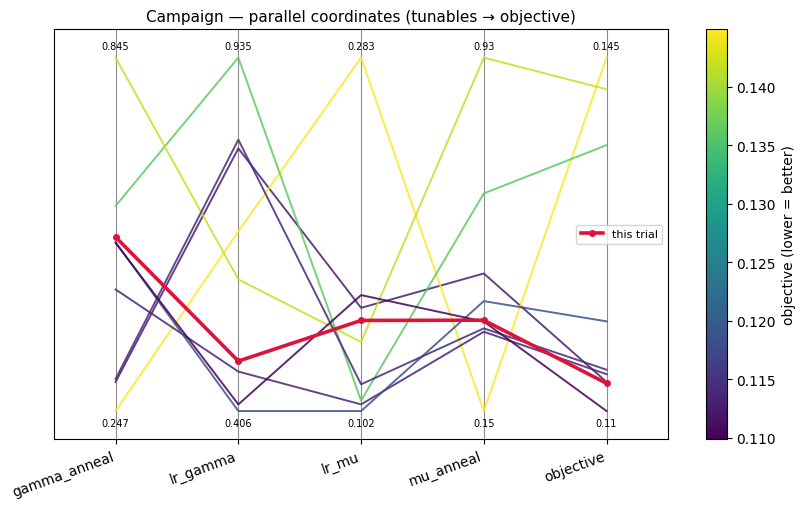

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 09 ran the highest-EI candidate (candidate 1, ei=3.91): `lr_mu=0.1486`, `mu_anneal=0.3504` (effective mu travel 0.123), `lr_gamma=0.4805`, `gamma_anneal=0.5416`. It completed in 8.0 min with objective **0.1126 +/- 0.0827** and **0 diverged cells**. Ranking: trial_08 0.1099 < **trial_09 0.1126** ~ trial_01 0.1127 < trial_05 0.1135 < trial_07 0.1140 < trial_06 0.1188 < trial_03 0.1362 < trial_04 0.1418 < trial_02 0.1449. Trial_08 stays best.

Aggregate accuracy: **mu rel-RMSE 71.1%** (RMSE 28.74, bias -6.13), between trial_08's 76.5% and trial_05's 56.6%; **gamma rel-RMSE 23.7%** (RMSE 2.39, bias -1.62).

Per-cell relative errors:
- **mu:** 1nW T05 +9.3%, T20 +148.2%, T60 -0.3%, T100 -8.8% | 3nW T05 +123.8%, T20 +29.1%, T60 -24.7%, T100 -39.8%.
- **gamma:** 1nW T05 -51.1%, T20 -27.0%, T60 -9.8%, T100 -1.3% | 3nW T05 -31.0%, T20 -9.4%, T60 +2.7%, T100 -0.7%.

This was a fine refinement just next to the new best (travel 0.123 vs trial_08's 0.134, gamma knobs close). It reproduced the good 1nW high-T mu behaviour (1nW T60 -0.3%, nearly exact) but not quite the whole of trial_08's gain: 1nW T100 slipped to -8.8% (trial_08 was -2.5%), and 3nW T60/T100 stayed at -24.7% / -39.8%. So the objective came out at 0.1126 — essentially dead level with trial_01 (0.1127) and just above trial_08. The result says the good band around the optimum is quite flat (0.1099-0.1140 across travels 0.097-0.134), with trial_08's slightly larger travel still the best of the group.

**Summary:** Trial 09 (lr_mu=0.1486, mu_anneal=0.3504, lr_gamma=0.4805, gamma_anneal=0.5416): objective 0.1126 +/- 0.0827 with 0 diverged cells; a fine refinement next to trial_08 reproduced the good 1nW high-T mu behaviour (T60 -0.3%) but only matched trial_01's level, so trial_08 (0.1099) stays the best.
**Key insight:** The good mu-travel band is flat to about +/-0.003 in objective (0.1099-0.1140 over travels 0.097-0.134), with trial_08's slightly larger travel the current best; tuning inside this band yields diminishing returns.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
**Notes for Anuar (not acted on).** Four consecutive divergence-free runs (05-09) spanning travels 0.082-0.134 all land within 0.1099-0.1188; the remaining error is dominated by features no schedule knob has moved: the 3nW high-T mu undershoot (~-25% to -40% in the two best runs) and the low-T gamma under-recovery (T05/T20 ~-50% / -27%). That is the standing structural argument (n_target- or power-adaptive steps); recorded only, not acted on.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = "Trial 09 (lr_mu=0.1486, mu_anneal=0.3504, lr_gamma=0.4805, gamma_anneal=0.5416): objective 0.1126 +/- 0.0827 with 0 diverged cells; a fine refinement next to trial_08 reproduced the good 1nW high-T mu behaviour (T60 -0.3%) but only matched trial_01's level, so trial_08 (0.1099) stays the best"      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = "The good mu-travel band is flat to about +/-0.003 in objective (0.1099-0.1140 over travels 0.097-0.134), with trial_08's slightly larger travel the current best; tuning inside this band yields diminishing returns"  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_09 | current best: trial_08


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_10.ipynb. Open it and follow its cells from the top.
